# Turner angle — three definitions compared

**Def 1 (store channel):**
`Tu = arctan[ρ₀(β²|∇S|² − α²|∇T|²) / (−gradrho2/ρ₀)]`
(numerator from constant-α/β linear model; denominator the MEASURED
JMD95 gradrho2).

**Def 2 (closed-set):** same numerator; denominator rebuilt from
the same T,S samples via the direct cross term:
`D = −ρ₀(α²|∇T|² + β²|∇S|² − 2αβ∇T·∇S)`.

**Def 3 (projection — Johnson et al. 2012; Whalen & Drushka 2025):**
`Tu = arctan[∇ρ·(α∇T + β∇S) / ∇ρ·(α∇T − β∇S)]`
with ∇ρ measured (full EOS).

**They are mathematically equivalent** under the exact linearized
EOS with constant α, β — substitute ∇ρ = ρ₀(β∇S − α∇T) into Def 3
and Defs 1–2 fall out.  They differ in practice because measured
∇ρ carries EOS nonlinearity and locally-varying α, β; away from
compensation that gap is a small correction, but AT compensation
the leading terms cancel and the gap dominates — the three forms
diverge precisely where Tu is interesting.  Def 3 is the
best-conditioned (measured ∇ρ enters LINEARLY in numerator and
denominator, so its errors partially cancel in the ratio) and is
the literature definition; positive angles = temperature-dominated
(their convention, arctan on −90..90°).

All dot products here use the co-located staggered-product form
(interp AFTER multiplying).  Undefined cores (∇ρ → 0) masked below
a visible floor.

## Section 1 — LOAD the store channel + grid

Def 1 comes from the SAVED frontal_structure store (regenerate it
first if stale — see the frontal_structure notebook Section 1).

In [1]:
# Section 1: frontal_structure store reader + shared grid.
import numpy as np
import matplotlib.pyplot as plt
import cmocean.cm as cmo

import dbof.io.filesystems as filesystems
import dbof.global_dataset_creation.zarr_dataset_global as zarr_dataset
import dbof.global_dataset_creation.zarr_grid_global as zarr_grid
from dbof.global_dataset_creation.subset_definitions import (
    get_subset_definition,
)

S3_ENDPOINT = "https://s3-west.nrp-nautilus.io"
BUCKET      = "dbof"
FOLDER      = "surface_fields"
RUN_ID      = "field_validation_v1"
PIPELINE    = "SURF"
DATE        = "2012-11-09 12:00:00"
DATE_PREFIX = "20121109_120000"

defn = get_subset_definition(PIPELINE, "frontal_structure")
fs, _ = filesystems.create_s3_filesystems(S3_ENDPOINT)
reader = zarr_dataset.GlobalZarrDatasetReader(
    bucket=BUCKET, folder=FOLDER, run_id=RUN_ID,
    dataset_name=defn["dataset_name"], date_prefix=DATE_PREFIX,
    fs=fs,
)
fs_grid, _ = filesystems.create_s3_filesystems(S3_ENDPOINT)
grid_reader = zarr_grid.GlobalGridZarrReader(
    bucket=BUCKET, folder="LLC4320_GRID_2D",
    dataset_name="llc4320_grid.zarr", fs=fs_grid,
)
XC, YC = grid_reader.lon, grid_reader.lat
print(f"store channels: {reader.channel_names}")

store channels: ['gradb2', 'gradsalt2', 'gradtheta2', 'gradeta2', 'gradrho2', 'turner_angle', 'density', 'buoyancy']


## Section 2 — Region selection

In [2]:
# Section 2: pick the region; re-run from here after changing it.
from dbof.plotting import regions

REGION       = "gulf_stream"   # <-- change me
ZOOM_HALF_KM = 100.0           # 200x200 km zoom box

_zoomable = [n for n, r in regions.REGIONS.items() if "zoom" in r]
assert REGION in _zoomable, f"pick one of {_zoomable}"
print(f"region: {REGION}  (options: {_zoomable})")

region: gulf_stream  (options: ['gulf_stream', 'so_atlantic', 'eq_pacific', 'kuroshio'])


## Section 3 — Defs 2 and 3, live

`calculate_grad_dot_tracer` is defined INLINE (notebook-only until
a definition is adopted); verbatim candidate for
`utils/native_gradient.py`.

In [3]:
# Section 3a: live closed-set (Def 2) + projection (Def 3), lazy.
import dbof.preprocessing.calculate_fields as calculate_fields
import dbof.utils.native_gradient as ng
from dbof.cli.generate_global import load_snapshot
from dbof.global_dataset_creation.data_sources import get_data_source
from dbof.global_dataset_creation.grid_setup import set_up_grid
from dbof.preprocessing.physical_constants import (
    ALPHA, BETA, RHO0_REFERENCE,
)

ds_grid, land_mask, xgrid = set_up_grid(PIPELINE, None)
ds_raw, ds_merge, it = load_snapshot(
    PIPELINE, DATE, ds_grid, ["Theta", "Salt"],
    surface_only=False, data_source=get_data_source(PIPELINE),
)
print(f"OSN iteration {it}  (store iteration {reader.iteration})")


def calculate_grad_dot_tracer(da_a, da_b, ds_grid, grid):
    """∇a·∇b with the products formed ON the staggered points.

    ax and bx are CO-LOCATED on the u-points (ay, by on the
    v-points), so the products need no pre-interpolation.
    Verbatim candidate for utils/native_gradient.py.
    Inputs: da_a, da_b (tracer-point DataArrays); ds_grid (dxC,
    dyC); grid (xgcm).  Outputs: ∇a·∇b at tracer points, lazy.
    Generated by LH and Claude
    """
    ax = grid.diff(da_a, 'X') / ds_grid.dxC
    bx = grid.diff(da_b, 'X') / ds_grid.dxC
    ay = grid.diff(da_a, 'Y') / ds_grid.dyC
    by = grid.diff(da_b, 'Y') / ds_grid.dyC
    return (grid.interp(ax * bx, 'X', boundary='fill')
            + grid.interp(ay * by, 'Y', boundary='fill'))


T, S = ds_merge.Theta, ds_merge.Salt
rho = calculate_fields.potential_density(ds_merge)

# -- Def 2 (closed-set, constant alpha/beta linear model) ---------
A = ALPHA**2 * ng.calculate_grad_squared_tracer(T, ds_merge, xgrid)
B = BETA**2 * ng.calculate_grad_squared_tracer(S, ds_merge, xgrid)
X = ALPHA * BETA * calculate_grad_dot_tracer(T, S, ds_merge, xgrid)
tu_closed = np.degrees(np.arctan(
    (RHO0_REFERENCE * (B - A))
    / (-RHO0_REFERENCE * (A + B - 2.0 * X))))
d_closed = np.abs(A + B - 2.0 * X)      # mask variable, Def 2

# -- Def 3 (projection; Johnson 2012 / Whalen & Drushka) ----------
P_T = calculate_grad_dot_tracer(rho, T, ds_merge, xgrid)  # ∇ρ·∇T
P_S = calculate_grad_dot_tracer(rho, S, ds_merge, xgrid)  # ∇ρ·∇S
P_R = calculate_grad_dot_tracer(rho, rho, ds_merge,
                                xgrid)                    # |∇ρ|²
tu_proj = np.degrees(np.arctan(
    (ALPHA * P_T + BETA * P_S) / (ALPHA * P_T - BETA * P_S)))

live_map = {"tu_closed": tu_closed, "d_closed": d_closed,
            "tu_proj": tu_proj, "d_proj": P_R}
print("lazy Defs 2-3 ready")

Opening 13 Kerchunk JSON files...
Parsing JSON metadata into Python dicts...
Creating lazy xarray datasets...
Computing delayed datasets...
Combining datasets by coordinates...
Dataset combined successfully.
OSN iteration 1473984  (store iteration 1473984)
lazy Defs 2-3 ready


In [4]:
# Section 3b: stitch + slice (shared plumbing) and store slice.
from dbof.plotting.live_fields import stitch_and_slice, slice_store

region_arrays = stitch_and_slice(
    live_map, ds_raw, ds_merge, XC, YC, [REGION], batch=2)
region_arrays.update(
    slice_store(reader, ["turner_angle"], XC, YC, [REGION]))
print("sliced:", sorted(region_arrays))

/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/xmitgcm/llcreader/llcmodel.py:322: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  data = np.arange(ifac * coords.dims[vname])
/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/xmitgcm/llcreader/llcmodel.py:324: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  data = np.arange(jfac * coords.dims[vname])


stitched + sliced: ['tu_closed', 'd_closed']


/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/xmitgcm/llcreader/llcmodel.py:322: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  data = np.arange(ifac * coords.dims[vname])
/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/xmitgcm/llcreader/llcmodel.py:324: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  data = np.arange(jfac * coords.dims[vname])


stitched + sliced: ['tu_proj', 'd_proj']
sliced: ['d_closed', 'd_proj', 'tu_closed', 'tu_proj', 'turner_angle']


## Section 4 — Masks

Defs 2–3 are undefined where their denominators vanish;
`FLOOR_PCT` masks the weakest x % of each mask variable.  Def 1
is shown unmasked (as stored).

In [5]:
# Section 4: mask the undefined cores (regional, tunable).
FLOOR_PCT = 1.0    # mask the weakest x% — tune me


def _masked(tu_key, d_key):
    """Regionally mask a Tu variant below its floor.
    Inputs: tu_key, d_key (str).  Outputs: (x, y, arr).
    Generated by LH and Claude
    """
    x, y, tu = region_arrays[tu_key][REGION]
    _, _, d = region_arrays[d_key][REGION]
    d = np.abs(d)
    floor = np.nanpercentile(d[np.isfinite(d)], FLOOR_PCT)
    out = np.where(d > floor, tu, np.nan)
    frac = 100.0 * np.mean(~np.isfinite(out) & np.isfinite(tu))
    print(f"{tu_key}: floor P{FLOOR_PCT} -> masked {frac:.2f}%")
    return x, y, out


DEFS = {
    "Def 1 (store)": region_arrays["turner_angle"][REGION],
    "Def 2 (closed-set)": _masked("tu_closed", "d_closed"),
    "Def 3 (projection, W&D)": _masked("tu_proj", "d_proj"),
}

tu_closed: floor P1.0 -> masked 0.90%
tu_proj: floor P1.0 -> masked 0.90%


In [8]:
# Quantify Def 2 vs Def 3 (same mask applied to both).
_, _, t2 = DEFS["Def 2 (closed-set)"]
_, _, t3 = DEFS["Def 3 (projection, W&D)"]
m = np.isfinite(t2) & np.isfinite(t3)
d = t2[m] - t3[m]
print(f"corr           : {np.corrcoef(t2[m], t3[m])[0, 1]:.4f}")
print(f"RMSE           : {np.sqrt(np.mean(d ** 2)):.2f} deg")
print(f"median |diff|  : {np.median(np.abs(d)):.2f} deg")
print(f"|diff| > 10 deg: {100 * np.mean(np.abs(d) > 10):.2f}%")
print(f"|diff| > 45 deg: {100 * np.mean(np.abs(d) > 45):.2f}%")

corr           : 0.8925
RMSE           : 23.68 deg
median |diff|  : 0.53 deg
|diff| > 10 deg: 11.11%
|diff| > 45 deg: 3.94%


## Section 5 — Maps: columns = definitions, rows = full / zoom

Fixed ±90° balance scale everywhere.  Gray in Defs 2–3 = masked
undefined core.  Remember the equivalence caveat: differences
between the columns are the EOS-nonlinearity/local-α,β content,
concentrated near compensated water.

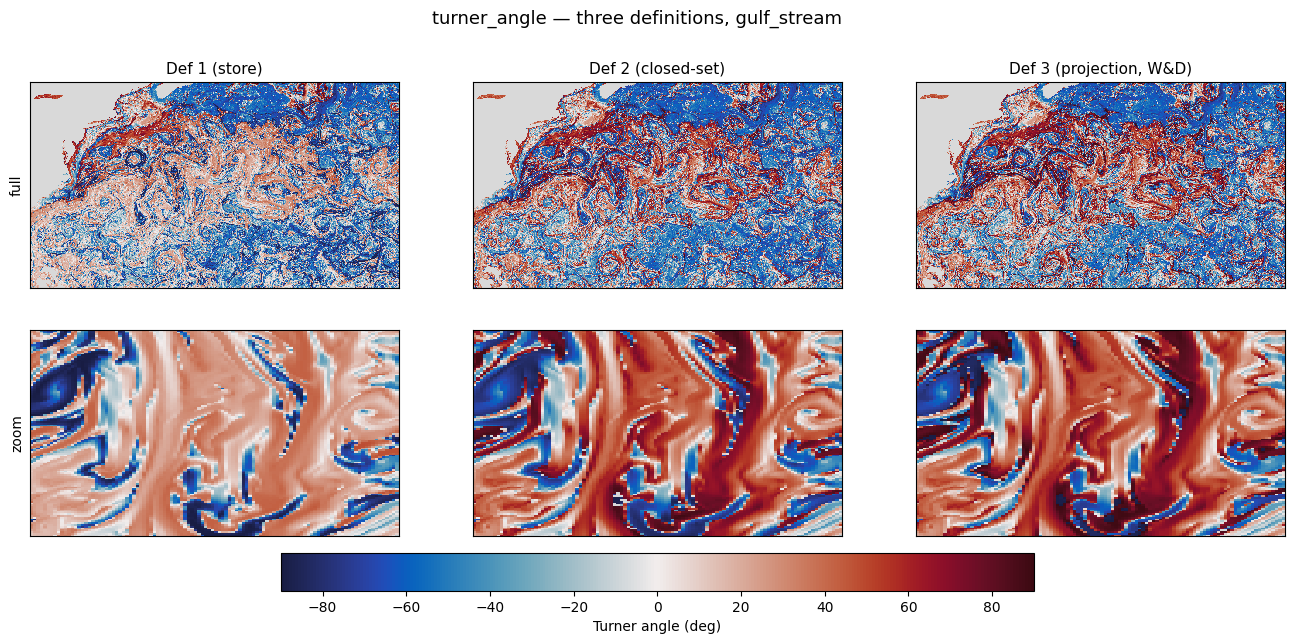

In [6]:
# Section 5: 2x3 comparison figure.
from dbof.plotting.pipeline_grids import LAND_COLOR

fig, axes = plt.subplots(2, 3, figsize=(5.4 * 3, 3.6 * 2))
pm = None
for col, (label, (x, y, arr)) in enumerate(DEFS.items()):
    for row, zoom in enumerate((False, True)):
        xx, yy, aa = (regions.crop_zoom(x, y, arr, REGION,
                                        half_km=ZOOM_HALF_KM)
                      if zoom else (x, y, arr))
        ax = axes[row, col]
        ax.set_facecolor(LAND_COLOR)
        pm = ax.pcolormesh(xx, yy, aa, cmap=cmo.balance,
                           vmin=-90, vmax=90, shading="nearest")
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel("zoom" if zoom else "full", fontsize=10)
    axes[0, col].set_title(label, fontsize=11)
fig.colorbar(pm, ax=list(axes.ravel()), orientation="horizontal",
             shrink=0.6, pad=0.03, label="Turner angle (deg)")
fig.suptitle(f"turner_angle \u2014 three definitions, {REGION}",
             fontsize=13)
plt.show()

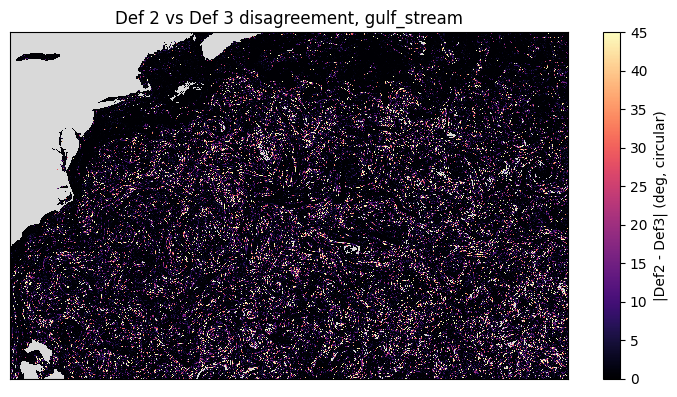

In [12]:
dd = np.full(t2.shape, np.nan)
dcirc = (t2 - t3 + 90.0) % 180.0 - 90.0
dd[np.isfinite(t2) & np.isfinite(t3)] = np.abs(
    dcirc[np.isfinite(t2) & np.isfinite(t3)])
x, y, _ = DEFS["Def 2 (closed-set)"]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.set_facecolor("0.85")
pm = ax.pcolormesh(x, y, dd, vmin=0, vmax=45, cmap="magma")
plt.colorbar(pm, ax=ax, label="|Def2 - Def3| (deg, circular)")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Def 2 vs Def 3 disagreement, {REGION}")
plt.show()

## Section 6 — Distributions

One line per definition.  The speckle signature is a spurious ±90°
pileup; the definitions' magnitude offsets show up as shifted bulk
structure.

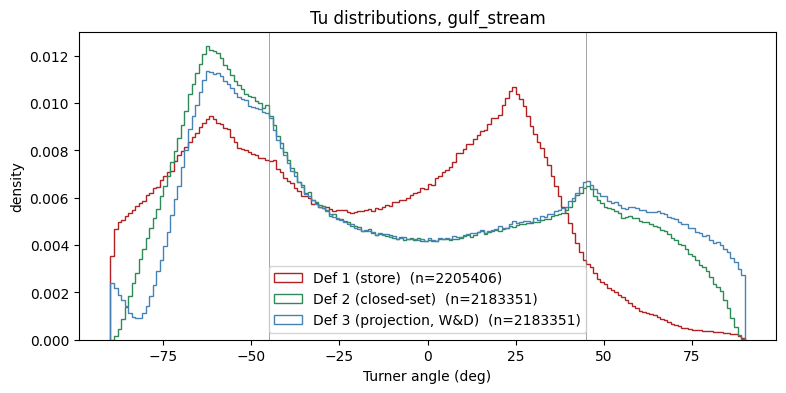

In [7]:
# Section 6: Tu histograms, all three definitions.
bins = np.linspace(-90, 90, 181)
fig, ax = plt.subplots(figsize=(9, 4))
for (label, (_, _, arr)), colr in zip(
        DEFS.items(), ("firebrick", "seagreen", "steelblue")):
    v = arr[np.isfinite(arr)]
    ax.hist(v, bins=bins, histtype="step", density=True,
            label=f"{label}  (n={v.size})", color=colr)
ax.set_xlabel("Turner angle (deg)")
ax.set_ylabel("density")
ax.axvline(45, color="gray", lw=0.5)
ax.axvline(-45, color="gray", lw=0.5)
ax.legend()
ax.set_title(f"Tu distributions, {REGION}")
plt.show()

## Findings

*(fill in after running)*

- Speckle ranking (LH: store least sparkly; magnitudes of
  Defs 2–3 differ strongly from Def 1 — the constant-α,β linear
  model vs the measured full-EOS ∇ρ):
- Def 3 is the Whalen & Drushka / Johnson et al. (2012)
  definition — leading candidate for the production channel:
- Masked fractions: 0.9%
- Decision: DEF 3